# G10 — Notebook 01 : Exploration du dataset Allociné (D05)

**Groupe 10** | CamemBERT-base × Allociné | Problématique P02  
**Objectif** : Explorer le dataset avant l'optimisation

---

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 1. Chargement du dataset

In [2]:
from src.data_loader import load_raw_dataset, dataset_stats

dataset = load_raw_dataset()
print(dataset)

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})


In [3]:
# Statistiques descriptives
dataset_stats(dataset)


── train (160000 exemples) ──
  Distribution des classes : {0: 79413, 1: 80587}
  Longueur moyenne (tokens approx.) : 91 ± 75
  Longueur max : 384 | min : 1

── validation (20000 exemples) ──
  Distribution des classes : {0: 10204, 1: 9796}
  Longueur moyenne (tokens approx.) : 92 ± 77
  Longueur max : 390 | min : 1

── test (20000 exemples) ──
  Distribution des classes : {1: 9592, 0: 10408}
  Longueur moyenne (tokens approx.) : 93 ± 77
  Longueur max : 380 | min : 1


## 2. Analyse de la longueur des critiques

C:\Users\Ultra Tech\AppData\Local\Temp\ipykernel_16492\1056017527.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([lengths], labels=['Train'])


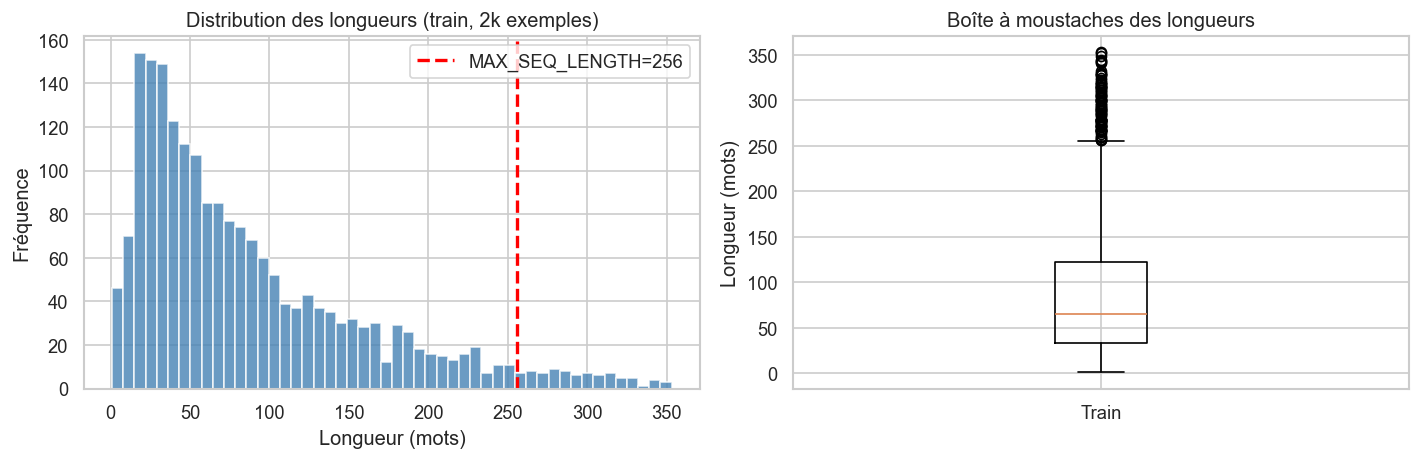

Critiques tronquées (>256 mots) : 4.0%


In [4]:
# Longueur des critiques (en mots)
train_data = dataset['train']
lengths = [len(ex['review'].split()) for ex in train_data.select(range(2000))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(256, color='red', lw=2, ls='--', label='MAX_SEQ_LENGTH=256')
axes[0].set_xlabel('Longueur (mots)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des longueurs (train, 2k exemples)')
axes[0].legend()

axes[1].boxplot([lengths], labels=['Train'])
axes[1].set_ylabel('Longueur (mots)')
axes[1].set_title('Boîte à moustaches des longueurs')

plt.tight_layout()
plt.savefig('../results/figures/length_distribution.png', bbox_inches='tight')
plt.show()

trunc_pct = sum(1 for l in lengths if l > 256) / len(lengths) * 100
print(f'Critiques tronquées (>256 mots) : {trunc_pct:.1f}%')

## 3. Exemple de critiques

In [6]:
# Afficher quelques exemples
label_names = {0: '😠 Négatif', 1: '😊 Positif'}

for label in [0, 1]:
    examples = [ex for ex in dataset['train'] if ex['label'] == label][:2]
    #print(f'\n{'='*60}')
    print(f'  {label_names[label]}')
    print('='*60)
    for ex in examples:
        print(f'\n"{ex["review"][:300]}..."')

  😠 Négatif

"Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via sa filière EuropaCorp ont de quoi faire naître la moquerie.Paris y est encore une fois montrée comm..."

"Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique dilatées sur plus de 70 minutes de bande VHS pourrave et revisitées par Korine à la sauce années 2000 : les dandys-punk de Kubrick ont laissé place à des papys lubriques déguisés en sa..."
  😊 Positif

"Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride...."

"Tout commence comme une comédie légère avant un drame soudain qui fait basculer le film dans un...suspense incroyable mâtiné d'une étude psychologique très fine des mécanismes qui régissent un couple,

## 4. Sous-échantillonnage pour CPU

In [7]:
from src.data_loader import balanced_subsample
from src.config import N_TRAIN_PER_CLASS, N_VAL_PER_CLASS

train_subset = balanced_subsample(dataset['train'], n_per_class=N_TRAIN_PER_CLASS)
val_subset = balanced_subsample(dataset['validation'], n_per_class=N_VAL_PER_CLASS)

print(f'Train subset : {len(train_subset)} exemples')
print(f'Val subset   : {len(val_subset)} exemples')

# Vérification de l'équilibre
train_labels = Counter([ex['label'] for ex in train_subset])
print(f'Distribution train : {dict(train_labels)}')

Train subset : 1000 exemples
Val subset   : 300 exemples
Distribution train : {1: 500, 0: 500}


## 5. Analyse du tokenizer CamemBERT

W0305 09:02:53.458000 16492 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 7b732e3f-a465-4a40-a675-dc482d7e6230)')' thrown while requesting HEAD https://huggingface.co/camembert-base/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


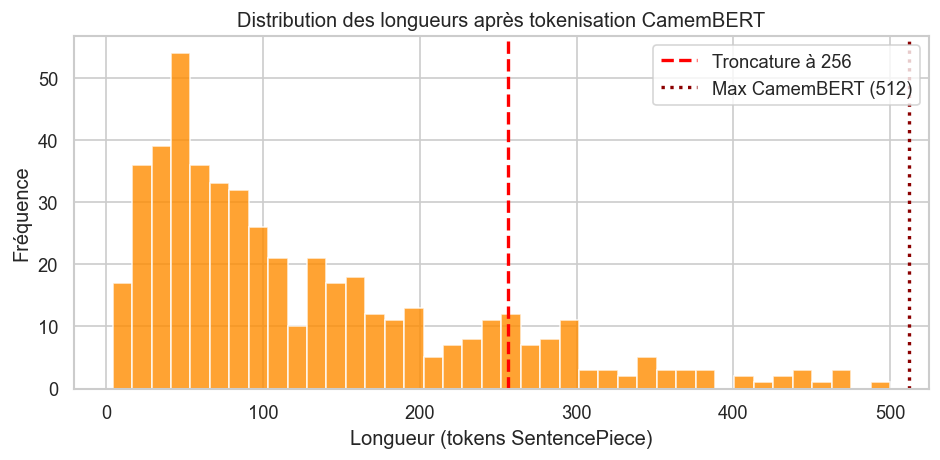

Longueur moyenne : 128 tokens
Médiane : 91 tokens
% tronqués à 256 : 13.4%


In [8]:
from src.model_setup import load_tokenizer

tokenizer = load_tokenizer()

# Longueur en tokens (≠ mots)
sample_texts = [ex['review'] for ex in train_subset[:500]]
token_lengths = [len(tokenizer.encode(t, truncation=False)) for t in sample_texts]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lengths, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(256, color='red', lw=2, ls='--', label='Troncature à 256')
ax.axvline(512, color='darkred', lw=2, ls=':', label='Max CamemBERT (512)')
ax.set_xlabel('Longueur (tokens SentencePiece)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des longueurs après tokenisation CamemBERT')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/token_lengths.png', bbox_inches='tight')
plt.show()

print(f'Longueur moyenne : {np.mean(token_lengths):.0f} tokens')
print(f'Médiane : {np.median(token_lengths):.0f} tokens')
print(f'% tronqués à 256 : {sum(1 for l in token_lengths if l > 256)/len(token_lengths)*100:.1f}%')

## 6. Aperçu du modèle CamemBERT

In [9]:
from src.model_setup import load_model, model_summary

# Charger avec le dropout par défaut (0.1)
model, device = load_model(dropout=0.1)
model_summary(model)
print(f'Device : {device}')

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  Modèle : CamemBERT-base (M04)
  Paramètres totaux    : 110.6 M
  Paramètres entraîn.  : 110.6 M
  Hidden dropout       : 0.1
  Attention dropout    : 0.1
  Classifier dropout   : 0.1

Device : cpu
